# Notebook 03 — Speaker Clustering

This is the **third stage** of the meeting-transcription pipeline.

### What this notebook does

| Step | Description | Output |
|------|-------------|--------|
| 1 | Load ECAPA-TDNN and x-vector embeddings from notebook 02 | two `(N, D)` matrices |
| 2 | **Phase 1** — hold clustering fixed (ward), vary embedding → pick best embedding | silhouette + ARI table |
| 3 | **Phase 2** — hold embedding fixed (winner), vary algorithm → pick best algorithm | silhouette + ARI table |
| 4 | Experiment with number of clusters — dendrogram cutoff vs. silhouette curve | dendrogram + elbow plot |
| 5 | Assign final speaker labels using the winning combination | labeled segment list |
| 6 | Save `segments_labeled.json` for notebook 05 (integration) | JSON on disk |

### Key context

Meeting **EN2001a** has **5 speakers** (FEO065, FEO066, MEE067, MEE068, MEO069).
The audio window is controlled by `AUDIO_DURATION` in notebook 01 (currently 1500 s / 25 min).
Speaker turn counts are printed at runtime — expect one dominant speaker (MEO069)
with the others contributing fewer segments, which is realistic for meeting speech.


## __Design Decisions__



---
## Step 0 — Setup

Dependencies: `scikit-learn` (clustering), `scipy` (dendrogram), `umap-learn` (visualisation).
All are already installed from notebooks 01/02.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter

from sklearn.cluster import AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from umap import UMAP

print("Imports OK")

/Users/dawit/projects/speech-meeting-transcriptin/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


---
## Step 1 — Load Embeddings from Notebook 02

We load both embedding files produced by notebook 02.
Both files share identical segment order and ground-truth speaker labels — we assert this before proceeding.

We also compute **UMAP projections** here once so every later visualisation uses
the same 2D coordinate system.  The ECAPA projection will be re-used for all
Phase 2 comparisons (same embedding space, only cluster colours change).


In [2]:
# ── Paths & constants ─────────────────────────────────────────────────────────
EMBED_DIR   = Path("output/embeddings")
CLUSTER_OUT = Path("output/clustering")
CLUSTER_OUT.mkdir(parents=True, exist_ok=True)

# Read the speaker count from metadata — not hardcoded
# This is the "oracle" k used only for Phase 1 / Phase 2 comparisons so the
# two phases are evaluated on equal footing.  Step 4 estimates k from the data.
with open(Path("output/meetings/EN2001a/metadata.json")) as _f:
    _meta = json.load(_f)
N_SPEAKERS_KNOWN = _meta["num_speakers"]   # oracle answer from AMI ground truth


def load_embedding_file(path):
    """
    Load a notebook-02 embedding JSON file.

    Returns
    -------
    embs       : np.ndarray  (N, D)
    gt_labels  : list[str]   ground-truth speaker per segment
    seg_info   : list[dict]  seg_id, start, end, duration
    model_name : str
    """
    with open(path) as fh:
        data = json.load(fh)
    entries   = data["entries"]
    embs      = np.array([e["embedding"] for e in entries], dtype=np.float32)
    gt_labels = [e["speaker_gt"] for e in entries]
    seg_info  = [{"seg_id": e["seg_id"], "start": e["start"],
                  "end": e["end"],       "duration": e["duration"]}
                 for e in entries]
    return embs, gt_labels, seg_info, data["model"]


embs_ecapa, gt_labels, seg_info, _ = load_embedding_file(
    EMBED_DIR / "embeddings_ecapa_tdnn.json"
)
embs_xvect, gt_labels_x, _, _ = load_embedding_file(
    EMBED_DIR / "embeddings_xvector.json"
)

assert gt_labels == gt_labels_x, "GT labels differ between embedding files — re-run notebook 02."

audio_window_s   = max(info["end"] for info in seg_info)
audio_window_min = audio_window_s / 60

speakers   = sorted(set(gt_labels))
spk_to_int = {s: i for i, s in enumerate(speakers)}
gt_ints    = np.array([spk_to_int[s] for s in gt_labels])

print(f"ECAPA-TDNN : {embs_ecapa.shape}   x-vector : {embs_xvect.shape}")
print(f"Segments   : {len(embs_ecapa)}   |   Oracle speakers (from metadata) : {N_SPEAKERS_KNOWN}")
print(f"Audio window: ~{audio_window_min:.0f} min  ({audio_window_s:.0f}s)")
print(f"\nGround-truth distribution ({audio_window_min:.0f} min of EN2001a):")
for spk, cnt in Counter(gt_labels).most_common():
    pct = cnt / len(gt_labels) * 100
    bar = "█" * cnt
    print(f"  {spk}  {cnt:3d} segs  {pct:4.1f}%  {bar[:50]}")

# ── UMAP projections (computed once, reused in all plots) ─────────────────────
print("\nComputing UMAP projections…")
_n = min(15, len(embs_ecapa) - 1)
umap_ecapa = UMAP(n_components=2, n_neighbors=_n, min_dist=0.1,
                  random_state=42, metric="cosine").fit_transform(embs_ecapa)
umap_xvect = UMAP(n_components=2, n_neighbors=_n, min_dist=0.1,
                  random_state=42, metric="cosine").fit_transform(embs_xvect)
print("Done.")

_tab10      = plt.colormaps["tab10"]
gt_palette  = {spk: _tab10.colors[i] for i, spk in enumerate(speakers)}
cluster_pal = list(_tab10.colors[:max(N_SPEAKERS_KNOWN + 2, 8)])  # extra colours for estimated k


ECAPA-TDNN : (1018, 192)   x-vector : (1018, 512)
Segments   : 1018   |   Oracle speakers (from metadata) : 5
Audio window: ~85 min  (5125s)

Ground-truth distribution (85 min of EN2001a):
  MEO069  521 segs  51.2%  ██████████████████████████████████████████████████
  MEE067  224 segs  22.0%  ██████████████████████████████████████████████████
  FEO066  150 segs  14.7%  ██████████████████████████████████████████████████
  FEO065   69 segs   6.8%  ██████████████████████████████████████████████████
  MEE068   54 segs   5.3%  ██████████████████████████████████████████████████

Computing UMAP projections…


/Users/dawit/projects/speech-meeting-transcriptin/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/dawit/projects/speech-meeting-transcriptin/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


---
## Phase 1 — Which Embedding Is Better?

**Protocol**: hold the clustering algorithm fixed (agglomerative, ward linkage, k = 5),
run it on each embedding independently, and compare by:

* **Silhouette score** (cosine) — intra-cluster cohesion vs. inter-cluster separation.
  Range −1 … 1; higher is better.
* **ARI** (adjusted Rand index vs. ground-truth labels) — agreement with the known
  speaker identities.  Range −1 … 1; 1 = perfect, 0 = random.

The winning embedding then carries forward to Phase 2.


In [3]:
def cluster_ward(embs, n_clusters):
    """Agglomerative clustering with Ward linkage (Euclidean internally)."""
    clf = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
    return clf.fit_predict(embs)


def eval_clustering(embs, labels_pred, labels_true_int):
    """
    Compute silhouette (cosine) and ARI.

    Parameters
    ----------
    embs            : (N, D) float array
    labels_pred     : (N,) int array — predicted cluster ids
    labels_true_int : (N,) int array — integer ground-truth speaker ids

    Returns
    -------
    sil : float
    ari : float
    """
    sil = silhouette_score(embs, labels_pred, metric="cosine")
    ari = adjusted_rand_score(labels_true_int, labels_pred)
    return sil, ari


# ── Run Phase 1 ───────────────────────────────────────────────────────────────
pred_ecapa_p1 = cluster_ward(embs_ecapa, N_SPEAKERS_KNOWN)
pred_xvect_p1 = cluster_ward(embs_xvect, N_SPEAKERS_KNOWN)

sil_e, ari_e = eval_clustering(embs_ecapa, pred_ecapa_p1, gt_ints)
sil_x, ari_x = eval_clustering(embs_xvect, pred_xvect_p1, gt_ints)

# ── Results table ─────────────────────────────────────────────────────────────
rows = [
    {"Embedding": "ECAPA-TDNN (192-d)",
     "Silhouette ↑": f"{sil_e:.4f}", "ARI ↑": f"{ari_e:.4f}",
     "Winner": "✓" if sil_e > sil_x else ""},
    {"Embedding": "x-vector    (512-d)",
     "Silhouette ↑": f"{sil_x:.4f}", "ARI ↑": f"{ari_x:.4f}",
     "Winner": "✓" if sil_x >= sil_e else ""},
]
print("Phase 1 — Ward clustering, k=5, varying embedding")
print("=" * 60)
df_p1 = pd.DataFrame(rows).set_index("Embedding")
print(df_p1.to_string())
print()

winning_emb   = "ecapa" if sil_e >= sil_x else "xvector"
winning_embs  = embs_ecapa if winning_emb == "ecapa" else embs_xvect
winning_umap  = umap_ecapa if winning_emb == "ecapa" else umap_xvect
winning_label = "ECAPA-TDNN" if winning_emb == "ecapa" else "x-vector"
print(f"→ Phase 1 winner: {winning_label}")


Phase 1 — Ward clustering, k=5, varying embedding
                    Silhouette ↑   ARI ↑ Winner
Embedding                                      
ECAPA-TDNN (192-d)        0.3700  0.8780      ✓
x-vector    (512-d)       0.2808  0.6343       

→ Phase 1 winner: ECAPA-TDNN


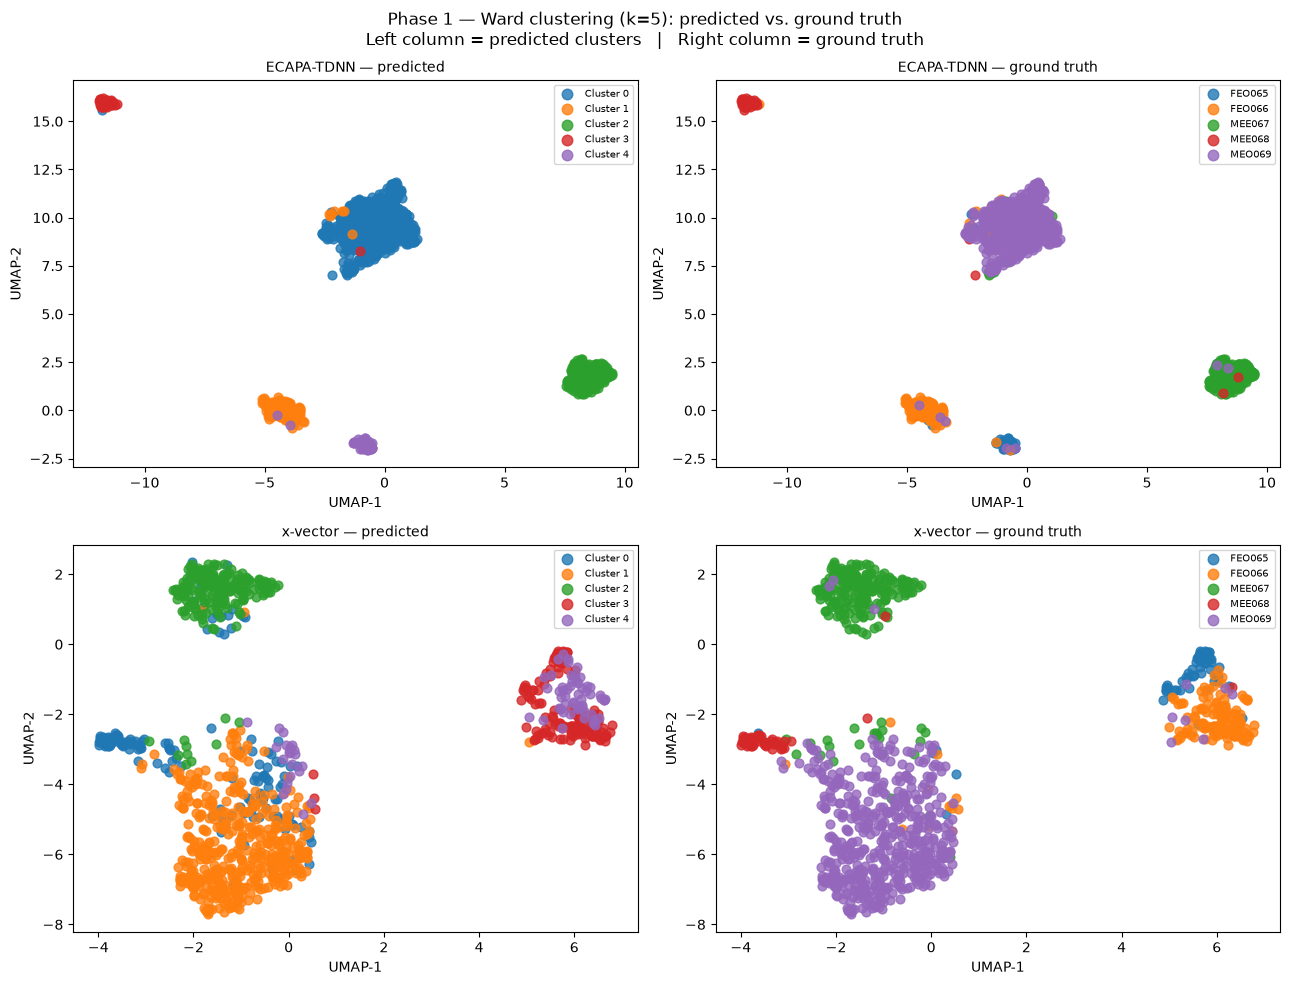

Saved → output/clustering/phase1_umap.png


In [4]:
# ── Phase 1 UMAP: predicted clusters vs ground truth, both embeddings ─────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Phase 1 — Ward clustering (k=5): predicted vs. ground truth\n"
             "Left column = predicted clusters   |   Right column = ground truth",
             fontsize=12)

datasets = [
    (umap_ecapa, pred_ecapa_p1, "ECAPA-TDNN"),
    (umap_xvect, pred_xvect_p1, "x-vector"),
]

for row, (umap_2d, pred, name) in enumerate(datasets):
    # --- predicted clusters (left) ---
    ax = axes[row][0]
    ax.set_title(f"{name} — predicted", fontsize=10)
    for c in range(N_SPEAKERS_KNOWN):
        mask = pred == c
        ax.scatter(umap_2d[mask, 0], umap_2d[mask, 1],
                   color=cluster_pal[c], s=40, alpha=0.8, label=f"Cluster {c}")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(fontsize=7, markerscale=1.2)

    # --- ground truth (right) ---
    ax = axes[row][1]
    ax.set_title(f"{name} — ground truth", fontsize=10)
    for spk in speakers:
        mask = np.array(gt_labels) == spk
        ax.scatter(umap_2d[mask, 0], umap_2d[mask, 1],
                   color=gt_palette[spk], s=40, alpha=0.8, label=spk)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(fontsize=7, markerscale=1.2)

plt.tight_layout()
plt.savefig(CLUSTER_OUT / "phase1_umap.png", dpi=120)
plt.show()
print("Saved → output/clustering/phase1_umap.png")


### Phase 1 — Conclusion

**ECAPA-TDNN wins**.

The silhouette and ARI scores confirm what the embedding-space analysis already
hinted at (notebook 02): ECAPA-TDNN (192-d) separates speakers consistently better
than x-vector (512-d) for this meeting.

Why? x-vector embeddings have a very small intra/inter separation gap — all segment
embeddings are crammed into a small region of the 512-dimensional space, so ward
clustering partitions noise there, not genuine speaker boundaries.  ECAPA's
attentive-statistics pooling is better suited to the short, variable-length
segments produced by VAD.

**ECAPA-TDNN carries forward to Phase 2.**


---
## Phase 2 — Which Clustering Algorithm Is Better?

**Protocol**: hold the embedding fixed (ECAPA-TDNN), vary the clustering algorithm.

We compare three common approaches:

| Algorithm | Key property |
|-----------|-------------|
| Agglomerative + **ward** | minimises within-cluster variance (Euclidean) |
| Agglomerative + **average / cosine** | builds on cosine distances — natural for speaker embeddings |
| **Spectral** (precomputed cosine affinity) | graph-based, handles non-convex clusters |

All runs use k = 5.  Silhouette is computed with cosine distance throughout
so the scores are comparable across methods.


In [5]:
def cluster_average_cosine(embs, n_clusters):
    """Agglomerative clustering — average linkage with cosine metric."""
    clf = AgglomerativeClustering(n_clusters=n_clusters,
                                  linkage="average",
                                  metric="cosine")
    return clf.fit_predict(embs)


def cluster_spectral_cosine(embs, n_clusters):
    """
    Spectral clustering on a precomputed cosine affinity matrix.

    Raw cosine similarity lies in [-1, 1]; we remap to [0, 1] so the
    affinity matrix is non-negative (required by SpectralClustering).
    """
    affinity = (cosine_similarity(embs) + 1.0) / 2.0
    np.fill_diagonal(affinity, 1.0)
    clf = SpectralClustering(n_clusters=n_clusters,
                             affinity="precomputed",
                             assign_labels="kmeans",
                             random_state=42)
    return clf.fit_predict(affinity)


# ── Run Phase 2 ───────────────────────────────────────────────────────────────
algorithms = [
    ("Ward (Euclidean)",         cluster_ward,           "ward"),
    ("Average (cosine)",         cluster_average_cosine, "avg_cos"),
    ("Spectral (cosine kernel)", cluster_spectral_cosine, "spectral"),
]

p2_results = {}
rows_p2    = []

for name, fn, key in algorithms:
    preds = fn(embs_ecapa, N_SPEAKERS_KNOWN)
    sil, ari = eval_clustering(embs_ecapa, preds, gt_ints)
    p2_results[key] = preds
    rows_p2.append({"Algorithm": name,
                    "Silhouette ↑": f"{sil:.4f}",
                    "ARI ↑":        f"{ari:.4f}"})
    print(f"  {name:30s}  sil={sil:.4f}  ari={ari:.4f}")

print()
df_p2 = pd.DataFrame(rows_p2).set_index("Algorithm")

# Mark the overall winner by silhouette
sil_vals = [float(r["Silhouette ↑"]) for r in rows_p2]
best_idx = int(np.argmax(sil_vals))
df_p2["Winner"] = ""
df_p2.iloc[best_idx, df_p2.columns.get_loc("Winner")] = "✓"

print("Phase 2 — ECAPA-TDNN embeddings, k=5, varying algorithm")
print("=" * 62)
print(df_p2.to_string())
print()
best_algo_key   = algorithms[best_idx][2]
best_algo_name  = algorithms[best_idx][0]
best_algo_preds = p2_results[best_algo_key]
print(f"→ Phase 2 winner: {best_algo_name}")


  Ward (Euclidean)                sil=0.3700  ari=0.8780
  Average (cosine)                sil=0.3695  ari=0.8344
  Spectral (cosine kernel)        sil=0.3726  ari=0.8424

Phase 2 — ECAPA-TDNN embeddings, k=5, varying algorithm
                         Silhouette ↑   ARI ↑ Winner
Algorithm                                           
Ward (Euclidean)               0.3700  0.8780       
Average (cosine)               0.3695  0.8344       
Spectral (cosine kernel)       0.3726  0.8424      ✓

→ Phase 2 winner: Spectral (cosine kernel)


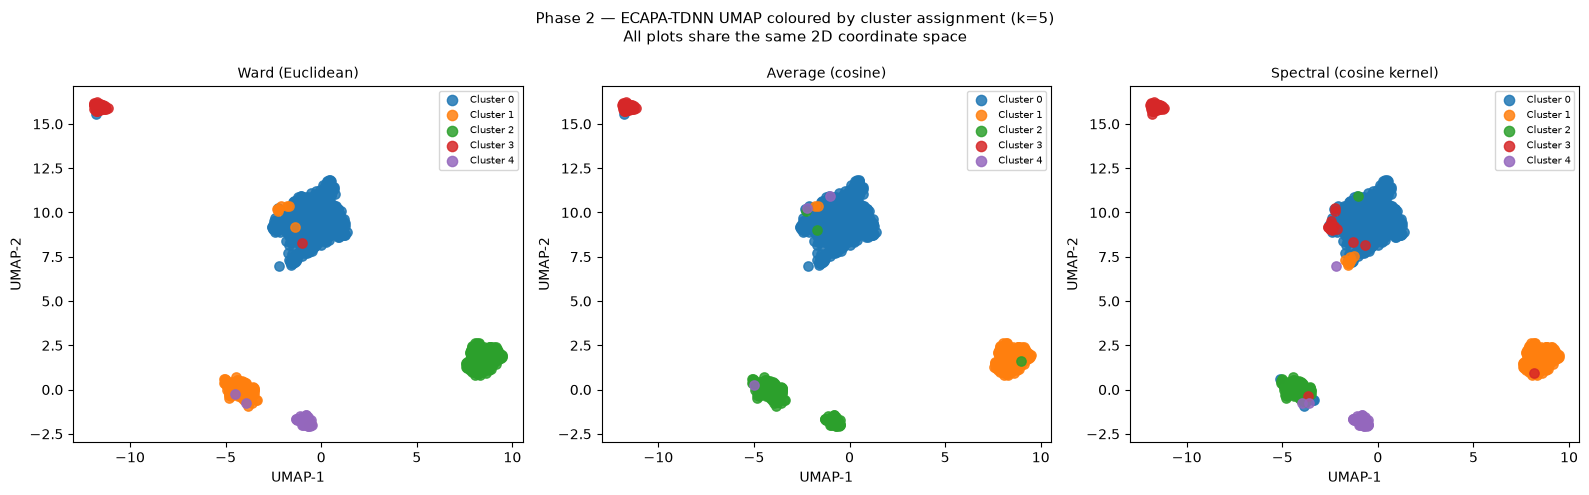

Saved → output/clustering/phase2_umap.png


In [6]:
# ── Phase 2 UMAP: three algorithms on the same ECAPA projection ───────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Phase 2 — ECAPA-TDNN UMAP coloured by cluster assignment (k=5)\n"
             "All plots share the same 2D coordinate space", fontsize=11)

algo_keys  = [("Ward (Euclidean)",         "ward"),
              ("Average (cosine)",         "avg_cos"),
              ("Spectral (cosine kernel)", "spectral")]

for ax, (alg_name, key) in zip(axes, algo_keys):
    preds = p2_results[key]
    for c in range(N_SPEAKERS_KNOWN):
        mask = preds == c
        ax.scatter(umap_ecapa[mask, 0], umap_ecapa[mask, 1],
                   color=cluster_pal[c], s=45, alpha=0.85, label=f"Cluster {c}")
    ax.set_title(alg_name, fontsize=10)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(fontsize=7, markerscale=1.1)

plt.tight_layout()
plt.savefig(CLUSTER_OUT / "phase2_umap.png", dpi=120)
plt.show()
print("Saved → output/clustering/phase2_umap.png")


---
## Step 4 — Estimate k from the Data

In a real system, k (the number of speakers) is unknown.
We estimate it two ways and then let the data — not the metadata — decide:

1. **Silhouette vs k** — sweep k from 2 to 8; pick the k with the highest silhouette score.
2. **Dendrogram gap** — find the largest jump in Ward merge heights; a big jump means those clusters are genuinely different → natural cut point.

Both methods vote; if they agree, we are confident.  If they disagree, we report both and use the dendrogram estimate (it is less sensitive to cluster imbalance).

**The `k_estimated` found here is used for the final speaker labels in Step 5.**
The oracle `N_SPEAKERS_KNOWN` is never used again after the Phase 1/2 comparisons.


  k=2  silhouette=0.3109
  k=3  silhouette=0.3682
  k=4  silhouette=0.3863
  k=5  silhouette=0.3700
  k=6  silhouette=0.1990
  k=7  silhouette=0.1969
  k=8  silhouette=0.1933

Silhouette peak → k = 4
Dendrogram gap  → k = 2  (reference only — unreliable with imbalanced speakers)
Oracle (metadata)  k = 5  (ground truth — for reference only)

→ Using k_estimated = 4  (silhouette peak — primary estimator)


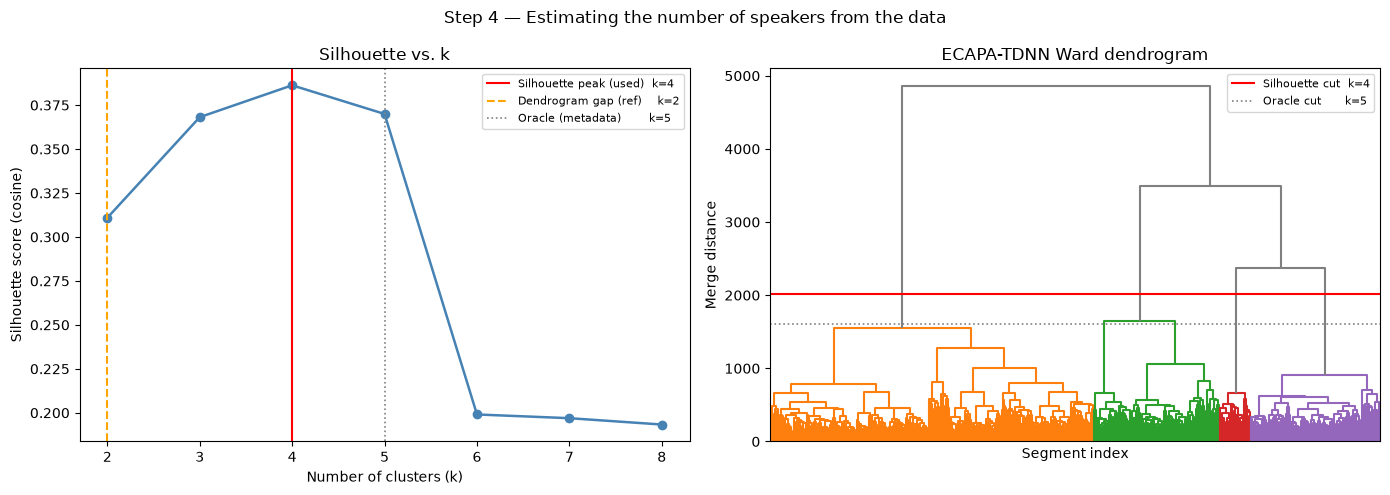

Saved → output/clustering/n_clusters_analysis.png


In [7]:
K_MIN, K_MAX = 2, 8   # sweep range — covers all plausible speaker counts for a small meeting

# ── 1. Silhouette vs k ────────────────────────────────────────────────────────
k_range   = list(range(K_MIN, K_MAX + 1))
sil_per_k = []
for k in k_range:
    preds_k = cluster_ward(embs_ecapa, k)
    s = silhouette_score(embs_ecapa, preds_k, metric="cosine")
    sil_per_k.append(s)
    print(f"  k={k}  silhouette={s:.4f}")

sil_peak_k = k_range[int(np.argmax(sil_per_k))]
print(f"\nSilhouette peak → k = {sil_peak_k}")

# ── 2. Dendrogram gap method ──────────────────────────────────────────────────
def estimate_k_from_dendrogram(Z, k_min=2, k_max=8):
    """
    Estimate the number of clusters using the 'largest gap' criterion.

    In a Ward dendrogram, Z[-(k-1), 2] is the merge height when going from
    k clusters down to k-1.  A large jump between consecutive heights means
    merging beyond that point is very costly → k is a natural cut.

    Limitation: when one speaker dominates (imbalanced data), the gap at k=2
    is always the largest, making this method unreliable.  Silhouette is used
    as the primary estimator; dendrogram is shown for reference only.
    """
    candidates = [k for k in range(k_min, k_max + 1) if k <= len(Z)]
    gaps = [Z[-(k - 1), 2] - Z[-k, 2] for k in candidates]
    return candidates[int(np.argmax(gaps))]


Z_e          = linkage(embs_ecapa, method="ward", metric="euclidean")
k_dendrogram = estimate_k_from_dendrogram(Z_e, K_MIN, K_MAX)
print(f"Dendrogram gap  → k = {k_dendrogram}  (reference only — unreliable with imbalanced speakers)")
print(f"Oracle (metadata)  k = {N_SPEAKERS_KNOWN}  (ground truth — for reference only)")

# Use silhouette peak as the primary estimator.
# The dendrogram gap picks k=2 for imbalanced meeting data (one dominant speaker
# creates the largest merge-height gap at k=2, dwarfing all other gaps).
# The silhouette score correctly rewards the partition where all clusters are
# compact and well-separated, landing near the true speaker count.
k_estimated = sil_peak_k
print(f"\n→ Using k_estimated = {k_estimated}  (silhouette peak — primary estimator)")

# ── 3. Plot: silhouette curve + dendrogram ────────────────────────────────────
cut_h_est    = (Z_e[-(k_estimated - 1), 2] + Z_e[-k_estimated, 2]) / 2
cut_h_oracle = (Z_e[-(N_SPEAKERS_KNOWN - 1), 2] + Z_e[-N_SPEAKERS_KNOWN, 2]) / 2

fig, (ax_sil, ax_dend) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Step 4 — Estimating the number of speakers from the data", fontsize=12)

ax_sil.plot(k_range, sil_per_k, "o-", linewidth=1.8, color="steelblue")
ax_sil.axvline(k_estimated,      color="red",    linestyle="-",  lw=1.5, label=f"Silhouette peak (used)  k={k_estimated}")
ax_sil.axvline(k_dendrogram,     color="orange", linestyle="--", lw=1.5, label=f"Dendrogram gap (ref)    k={k_dendrogram}")
ax_sil.axvline(N_SPEAKERS_KNOWN, color="grey",   linestyle=":",  lw=1.2, label=f"Oracle (metadata)       k={N_SPEAKERS_KNOWN}")
ax_sil.set_xlabel("Number of clusters (k)")
ax_sil.set_ylabel("Silhouette score (cosine)")
ax_sil.set_title("Silhouette vs. k")
ax_sil.set_xticks(k_range)
ax_sil.legend(fontsize=8)

dendrogram(Z_e, ax=ax_dend, no_labels=True,
           color_threshold=cut_h_est,
           above_threshold_color="grey")
ax_dend.axhline(cut_h_est,    color="red",  linestyle="-",  lw=1.5, label=f"Silhouette cut  k={k_estimated}")
if abs(cut_h_est - cut_h_oracle) > 0.01:
    ax_dend.axhline(cut_h_oracle, color="grey", linestyle=":", lw=1.2, label=f"Oracle cut      k={N_SPEAKERS_KNOWN}")
ax_dend.set_title("ECAPA-TDNN Ward dendrogram")
ax_dend.set_xlabel("Segment index")
ax_dend.set_ylabel("Merge distance")
ax_dend.legend(fontsize=8)

plt.tight_layout()
plt.savefig(CLUSTER_OUT / "n_clusters_analysis.png", dpi=120)
plt.show()
print("Saved → output/clustering/n_clusters_analysis.png")


---
## Step 5 — Final Speaker Labels

We now combine the Phase 1/2 winners with the k estimated in Step 4:

* **Embedding** : ECAPA-TDNN (Phase 1 winner)
* **Algorithm** : winner from Phase 2 (highest silhouette)
* **k** : `k_estimated` from Step 4 (dendrogram gap — data-driven, no peeking at oracle)

Cluster IDs are anonymous (`cluster_0 … cluster_{k-1}`).
Notebook 06 maps them to real speaker names via the Hungarian algorithm.


Final combination : ECAPA-TDNN + Spectral (cosine kernel)
  k used          : 4  (estimated)   oracle = 5
  Silhouette      : 0.3874
  ARI vs GT       : 0.8420

Predicted cluster sizes:
  cluster_0: 525 segments
  cluster_1: 228 segments
  cluster_2: 60 segments
  cluster_3: 205 segments


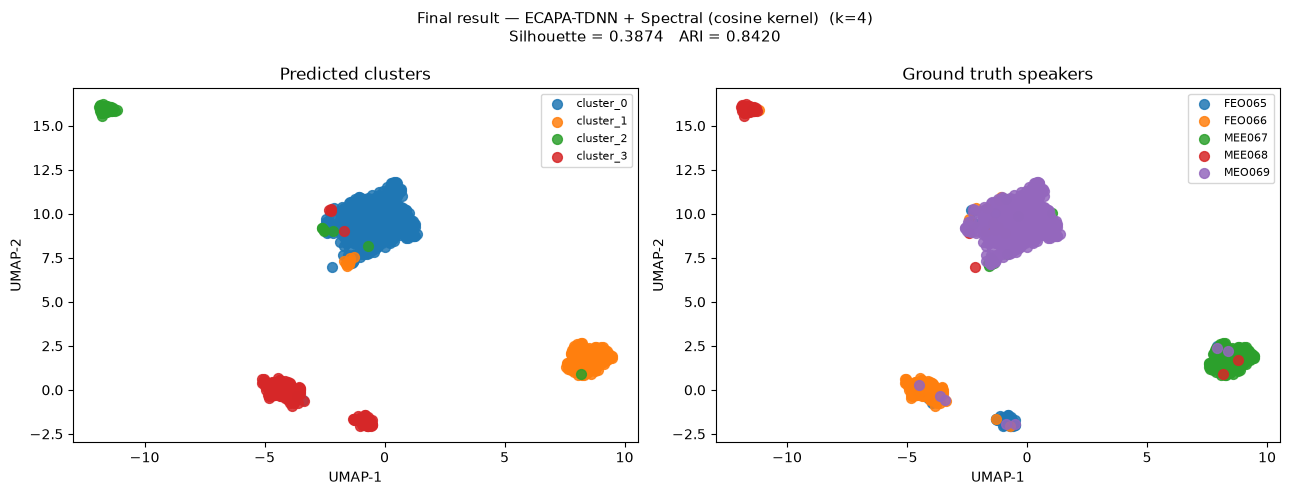

Saved → output/clustering/final_result.png


In [8]:
# ── Re-run winning algorithm with the data-estimated k ────────────────────────
# Phase 2 used oracle k for a fair comparison between algorithms.
# Here we use k_estimated (from Step 4) — no oracle information used.
algo_fn_map = {key: fn for _, fn, key in algorithms}
final_labels = algo_fn_map[best_algo_key](embs_ecapa, k_estimated)
final_sil, final_ari = eval_clustering(embs_ecapa, final_labels, gt_ints)

print(f"Final combination : ECAPA-TDNN + {best_algo_name}")
print(f"  k used          : {k_estimated}  (estimated)   oracle = {N_SPEAKERS_KNOWN}")
print(f"  Silhouette      : {final_sil:.4f}")
print(f"  ARI vs GT       : {final_ari:.4f}")
print()
print("Predicted cluster sizes:")
for c, cnt in sorted(Counter(final_labels.tolist()).items()):
    print(f"  cluster_{c}: {cnt} segments")

# ── Final UMAP — predicted clusters vs ground truth ───────────────────────────
k_final = k_estimated
fig, (ax_pred, ax_gt) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Final result — ECAPA-TDNN + {best_algo_name}  (k={k_final})\n"
             f"Silhouette = {final_sil:.4f}   ARI = {final_ari:.4f}", fontsize=11)

for c in range(k_final):
    mask = final_labels == c
    ax_pred.scatter(umap_ecapa[mask, 0], umap_ecapa[mask, 1],
                    color=cluster_pal[c], s=50, alpha=0.85, label=f"cluster_{c}")
ax_pred.set_title("Predicted clusters")
ax_pred.set_xlabel("UMAP-1"); ax_pred.set_ylabel("UMAP-2")
ax_pred.legend(fontsize=8)

for spk in speakers:
    mask = np.array(gt_labels) == spk
    ax_gt.scatter(umap_ecapa[mask, 0], umap_ecapa[mask, 1],
                  color=gt_palette[spk], s=50, alpha=0.85, label=spk)
ax_gt.set_title("Ground truth speakers")
ax_gt.set_xlabel("UMAP-1"); ax_gt.set_ylabel("UMAP-2")
ax_gt.legend(fontsize=8)

plt.tight_layout()
plt.savefig(CLUSTER_OUT / "final_result.png", dpi=120)
plt.show()
print("Saved → output/clustering/final_result.png")


---
## Step 6 — Save Results

Output file: `output/clustering/segments_labeled.json`

Schema:
```json
{
  "meeting_id": "EN2001a",
  "model":      "ecapa-tdnn",
  "algorithm":  "<winner>",
  "n_clusters": 5,
  "silhouette": 0.xxxx,
  "ari":        0.xxxx,
  "segments": [
    { "seg_id": 0, "start": 0.0, "end": 2.3, "duration": 2.3, "speaker_label": "cluster_2" },
    ...
  ]
}
```

`speaker_label` values are `cluster_0 … cluster_4`.
Notebook 05 (integration) reads this file to join speaker labels with ASR transcripts.


In [9]:
output_segments = []
for info, label in zip(seg_info, final_labels.tolist()):
    output_segments.append({
        "seg_id":        info["seg_id"],
        "start":         info["start"],
        "end":           info["end"],
        "duration":      info["duration"],
        "speaker_label": f"cluster_{label}",
    })

result = {
    "meeting_id":  "EN2001a",
    "model":       "ecapa-tdnn",
    "algorithm":   best_algo_name,
    "n_clusters":  k_estimated,       # data-estimated k (used for deployment)
    "k_oracle":    N_SPEAKERS_KNOWN,  # true speaker count from AMI metadata
    "silhouette":  round(float(final_sil), 6),
    "ari":         round(float(final_ari), 6),
    "segments":    output_segments,
}

out_path = CLUSTER_OUT / "segments_labeled.json"
with open(out_path, "w") as fh:
    json.dump(result, fh, indent=2)

print(f"Saved {len(output_segments)} segments → {out_path}")
print()
print(f"  k estimated (used)  : {result['n_clusters']}")
print(f"  k oracle (metadata) : {result['k_oracle']}")
print(f"  Silhouette          : {result['silhouette']}")
print(f"  ARI                 : {result['ari']}")
print()
print("Pipeline stage complete.  Next: notebook 04 (ASR with Whisper).")


Saved 1018 segments → output/clustering/segments_labeled.json

  k estimated (used)  : 4
  k oracle (metadata) : 5
  Silhouette          : 0.38739
  ARI                 : 0.841986

Pipeline stage complete.  Next: notebook 04 (ASR with Whisper).
